In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import json, gzip
from datetime import datetime
from math import isnan

from tqdm import tqdm

pd.set_option("display.max_colwidth", None)

In [11]:
with open("../../data/candidates.jsonl", "r") as f:
    candidates = [json.loads(line) for line in tqdm(f) if line.strip()]
    print(len(candidates))

100000it [00:22, 4444.24it/s]


100000


In [233]:
def json_to_df(candidates_data):
    
    # main keys - candidate_id, profile, career_history, education, skills, redrob_signals
    
    profile_data, career_data, education_data = [], [], []
    skills_data, certifications_data, languages_data = [], [], []
    redrob_signals_data = []
    
    for data in tqdm(candidates_data):
    
        candidate_id = data["candidate_id"]
        
        profile = data["profile"]
        name, headline, summary = profile["anonymized_name"], profile["headline"], profile["summary"]
        location, country = profile["location"], profile["country"]
        yoe, current_title = float(profile["years_of_experience"]), profile["current_title"]
        current_company, current_company_size, current_industry = profile["current_company"], profile["current_company_size"], profile["current_industry"]
        profile_data.append([candidate_id, name, headline, summary, location, country, yoe, current_title, current_company, current_company_size, current_industry])
        
        career = data["career_history"]
        for career_item in career:
            company, title = career_item["company"], career_item["title"]
            start_date = datetime.strptime(career_item["start_date"], "%Y-%m-%d")
            end_date = datetime.strptime(career_item["end_date"], "%Y-%m-%d") if career_item["end_date"] else ""
            duration_months, is_current = float(career_item['duration_months']), career_item["is_current"]
            industry, company_size = career_item["industry"], career_item["company_size"]
            career_data.append([candidate_id, title, company, start_date, end_date, duration_months, is_current, industry, company_size])
        
        education = data["education"]
        for edu in education:
            institution, tier = edu["institution"], edu["tier"]
            degree, field_of_study, grade = edu["degree"], edu["field_of_study"], edu["grade"]
            start_year, end_year = int(edu["start_year"]), int(edu["end_year"])
            education_data.append([candidate_id, degree, field_of_study, grade, institution, tier, start_year, end_year])
            
        skills = data["skills"]
        for skill in skills:
            name, proficiency = skill["name"], skill["proficiency"]
            endorsements, duration_months = int(skill["endorsements"]), float(skill["duration_months"])
            skills_data.append([candidate_id, name, proficiency, endorsements, duration_months])
    
        certifications = data["certifications"]
        for certification in certifications:
            name, issuer, year = certification["name"], certification["issuer"], int(certification["year"])
            certifications_data.append([candidate_id, name, issuer, year])
            
        languages = data["languages"]
        for lang in languages:
            language, proficiency = lang["language"], lang["proficiency"]
            languages_data.append([candidate_id, language, proficiency])
            
        redrob_data = data["redrob_signals"]
        redrob_signals_data.append([candidate_id, 
            redrob_data["profile_completeness_score"], 
            redrob_data["signup_date"], redrob_data["last_active_date"],
            redrob_data["open_to_work_flag"], 
            redrob_data["profile_views_received_30d"],
            redrob_data["applications_submitted_30d"], 
            redrob_data["recruiter_response_rate"],
            redrob_data["avg_response_time_hours"], 
            redrob_data["skill_assessment_scores"],
            redrob_data["connection_count"], 
            redrob_data["endorsements_received"],
            redrob_data["notice_period_days"], 
            redrob_data["expected_salary_range_inr_lpa"],
            redrob_data["preferred_work_mode"], redrob_data["willing_to_relocate"],
            redrob_data["github_activity_score"], redrob_data["search_appearance_30d"],
            redrob_data["saved_by_recruiters_30d"], redrob_data["interview_completion_rate"],
            redrob_data["offer_acceptance_rate"], redrob_data["verified_email"],
            redrob_data["verified_phone"], redrob_data["linkedin_connected"]
        ])
        
        

    profile_df = pd.DataFrame(profile_data, columns=["candidate_id", "name", "headline", "summary", "location", "country", "years_of_experience", "current_title", "current_company", "current_company_size", "current_industry"])
    profile_df.to_csv("profile_data.csv", index=False)
    
    career_df = pd.DataFrame(career_data, columns=["candidate_id", "title", "company", "start_date", "end_date", "duration_months", "is_current", "industry", "company_size"])
    career_df.to_csv("career_data.csv", index=True)
    
    education_df = pd.DataFrame(education_data, columns=["candidate_id", "degree", "field_of_study", "grade", "institution", "tier", "start_year", "end_year"])
    education_df.to_csv("education_data.csv", index=True)
    
    skills_df = pd.DataFrame(skills_data, columns=["candidate_id", "name", "proficiency", "endorsements", "duration_months"])
    skills_df.to_csv("skills_data.csv", index=True)
    
    certifications_df = pd.DataFrame(certifications_data, columns=["candidate_id", "name", "issuer", "year"])
    certifications_df.to_csv("certifications_data.csv", index=True)
    
    languages_df = pd.DataFrame(languages_data, columns=["candidate_id", "language", "proficiency"])
    languages_df.to_csv("languages_data.csv", index=True)
    
    redrob_df = pd.DataFrame(redrob_signals_data, columns=["candidate_id", "profile_completeness_score", "signup_date", "last_active_date",
            "open_to_work_flag", "profile_views_received_30d",
            "applications_submitted_30d", "recruiter_response_rate",
            "avg_response_time_hours", "skill_assessment_scores",
            "connection_count", "endorsements_received",
            "notice_period_days", "expected_salary_range_inr_lpa",
            "preferred_work_mode", "willing_to_relocate",
            "github_activity_score", "search_appearance_30d",
            "saved_by_recruiters_30d", "interview_completion_rate",
            "offer_acceptance_rate", "verified_email",
            "verified_phone", "linkedin_connected"])
    redrob_df.to_csv("redrob_signals.csv", index=True)
    
    return profile_df, career_df, education_df, skills_df, certifications_df, languages_df, redrob_df

# profile_df, career_df, education_df, skills_df, certifications_df, languages_df, redrob_df = json_to_df(candidates_data=candidates)

profile_df = pd.read_csv("profile_data.csv")
career_df = pd.read_csv("career_data.csv")
education_df = pd.read_csv("education_data.csv")
skills_df = pd.read_csv("skills_data.csv")
certifications_df = pd.read_csv("certifications_data.csv")
languages_df = pd.read_csv("languages_data.csv")
redrob_df = pd.read_csv("redrob_signals.csv")

career_df["start_date"] = career_df["start_date"].apply(lambda x: datetime.strptime(x[:10], "%Y-%m-%d"))
career_df["end_date"] = career_df["end_date"].apply(lambda x: "" if ((not isinstance(x, str)) and isnan(x)) else datetime.strptime(x[:10], "%Y-%m-%d"))
career_df["duration_months"] = career_df["duration_months"].apply(lambda x: float(x))

education_df["start_year"] = education_df["start_year"].apply(lambda x: int(x))
education_df["end_year"] = education_df["end_year"].apply(lambda x: int(x))

skills_df["endorsements"] = skills_df["endorsements"].apply(lambda x: int(x))
skills_df["duration_months"] = skills_df["duration_months"].apply(lambda x: float(x))

In [235]:
sub_df = career_df[career_df["end_date"] != ""]
sub_df["end_date"] = pd.to_datetime(sub_df["end_date"])
sub_df["months"] = (sub_df["end_date"] - sub_df["start_date"]).apply(lambda x: x.days / 30)
print(sub_df[sub_df["months"] == sub_df["duration_months"]]["candidate_id"].nunique())
sub_df[sub_df["months"] == sub_df["duration_months"]]

C:\Users\Dell\AppData\Local\Temp\ipykernel_7348\2326437304.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df["end_date"] = pd.to_datetime(sub_df["end_date"])


81492


C:\Users\Dell\AppData\Local\Temp\ipykernel_7348\2326437304.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df["months"] = (sub_df["end_date"] - sub_df["start_date"]).apply(lambda x: x.days / 30)


,Unnamed: 0,candidate_id,title,company,start_date,end_date,duration_months,is_current,industry,company_size,months
1,1,CAND_0000001,Analytics Engineer,Dunder Mifflin,2019-07-03,2024-01-08,55.0,False,Paper Products,201-500,55.0
3,3,CAND_0000002,Operations Manager,Wipro,2021-09-13,2022-11-07,14.0,False,IT Services,10001+,14.0
4,4,CAND_0000002,Marketing Manager,Acme Corp,2017-03-08,2021-08-14,54.0,False,Manufacturing,201-500,54.0
5,5,CAND_0000002,Marketing Manager,Dunder Mifflin,2014-01-23,2017-03-08,38.0,False,Paper Products,201-500,38.0
8,8,CAND_0000004,Operations Manager,Infosys,2023-07-28,2025-03-19,20.0,False,IT Services,10001+,20.0
...,...,...,...,...,...,...,...,...,...,...,...
300165,300165,CAND_0099999,Full Stack Developer,Stark Industries,2022-04-18,2023-08-11,16.0,False,Manufacturing,1001-5000,16.0
300167,300167,CAND_0100000,Customer Support,Stark Industries,2022-03-05,2023-08-27,18.0,False,Manufacturing,1001-5000,18.0
300168,300168,CAND_0100000,Customer Support,Wayne Enterprises,2018-06-24,2022-02-03,44.0,False,Conglomerate,10001+,44.0
300169,300169,CAND_0100000,Accountant,Infosys,2015-09-08,2018-06-24,34.0,False,IT Services,10001+,34.0


In [237]:
# total experience as per career history > total experience as per profile
total_exp_df = career_df.groupby("candidate_id", as_index=False).agg({'duration_months': lambda x: round(x.sum() / 12, ndigits=2)})
total_exp_df = total_exp_df.merge(profile_df[["candidate_id", "years_of_experience"]], on="candidate_id", how="left")
total_exp_df[total_exp_df["duration_months"] < total_exp_df["years_of_experience"]]

total_exp_df["exp_diff"] = total_exp_df["years_of_experience"] - total_exp_df["duration_months"]
print(total_exp_df[total_exp_df["exp_diff"] > 10]["candidate_id"].nunique())
total_exp_df[total_exp_df["exp_diff"] > 10]

19


,candidate_id,duration_months,years_of_experience,exp_diff
3429,CAND_0003430,0.92,13.7,12.78
5290,CAND_0005291,0.92,12.8,11.88
7412,CAND_0007413,1.33,13.3,11.97
24751,CAND_0024752,0.67,14.9,14.23
25578,CAND_0025579,1.00,12.9,11.90
33130,CAND_0033131,1.33,12.7,11.37
36298,CAND_0036299,0.67,12.2,11.53
38430,CAND_0038431,1.33,15.0,13.67
52477,CAND_0052478,1.33,12.4,11.07
55991,CAND_0055992,6.67,16.9,10.23


In [229]:
np.histogram(total_exp_df["exp_diff"], bins=np.linspace(total_exp_df["exp_diff"].min(), total_exp_df["exp_diff"].max(), 11))

(array([    1,     7,     5,     7,     4, 99951,     0,     2,    11,
           12], dtype=int64),
 array([-15.42 , -12.455,  -9.49 ,  -6.525,  -3.56 ,  -0.595,   2.37 ,
          5.335,   8.3  ,  11.265,  14.23 ]))

In [25]:
combined_company_data = profile_df[["candidate_id", 'current_title', "current_company", "current_company_size", "current_industry"]].merge(career_df[career_df["is_current"]][["candidate_id", "title", "company", "industry", "company_size"]], on="candidate_id", how="left")
combined_company_data[
    (combined_company_data["current_title"] != combined_company_data["title"]) |
    (combined_company_data["current_company"] != combined_company_data["company"]) |
    (combined_company_data["current_company_size"] != combined_company_data["company_size"]) |
    (combined_company_data["current_industry"] != combined_company_data["industry"])
]

,candidate_id,current_title,current_company,current_company_size,current_industry,title,company,industry,company_size


In [38]:
country_locations = {country: sorted(profile_df[profile_df["country"] == country]["location"].unique().tolist()) for country in profile_df["country"].unique().tolist()}
country_locations

{'Canada': ['Toronto'],
 'India': ['Ahmedabad, Gujarat',
  'Bangalore, Karnataka',
  'Bhubaneswar, Odisha',
  'Chandigarh, Chandigarh',
  'Chennai, Tamil Nadu',
  'Coimbatore, Tamil Nadu',
  'Delhi, Delhi',
  'Gurgaon, Haryana',
  'Hyderabad, Telangana',
  'Indore, Madhya Pradesh',
  'Jaipur, Rajasthan',
  'Kochi, Kerala',
  'Kolkata, West Bengal',
  'Mumbai, Maharashtra',
  'Noida, Uttar Pradesh',
  'Pune, Maharashtra',
  'Trivandrum, Kerala',
  'Vizag, Andhra Pradesh'],
 'USA': ['Austin', 'New York', 'San Francisco', 'Seattle'],
 'Australia': ['Sydney'],
 'UK': ['London'],
 'UAE': ['Dubai'],
 'Germany': ['Berlin'],
 'Singapore': ['Singapore']}

## Potential Honeypots

In [182]:
#####################################################################

print(skills_df[(skills_df["proficiency"] == "expert") & (skills_df["duration_months"] == 0)]["candidate_id"].nunique())
skills_df[(skills_df["proficiency"] == "expert") & (skills_df["duration_months"] == 0)]

21


,Unnamed: 0,candidate_id,name,proficiency,endorsements,duration_months
34189,34189,CAND_0003582,MLflow,expert,2,0.0
34190,34190,CAND_0003582,Photoshop,expert,2,0.0
34194,34194,CAND_0003582,Content Writing,expert,0,0.0
153543,153543,CAND_0016000,TypeScript,expert,0,0.0
153544,153544,CAND_0016000,Go,expert,1,0.0
...,...,...,...,...,...,...
915540,915540,CAND_0095317,dbt,expert,0,0.0
917057,917057,CAND_0095480,Agile,expert,2,0.0
917058,917058,CAND_0095480,React,expert,2,0.0
917062,917062,CAND_0095480,Snowflake,expert,3,0.0


In [191]:
#####################################################################

print(skills_df[(skills_df["proficiency"] == "advanced") & (skills_df["duration_months"] < 3)]["candidate_id"].nunique())
skills_df[(skills_df["proficiency"] == "advanced") & (skills_df["duration_months"] < 3)]

2


,Unnamed: 0,candidate_id,name,proficiency,endorsements,duration_months
425105,425105,CAND_0044252,Redis,advanced,0,2.0
647647,647647,CAND_0067443,Salesforce CRM,advanced,2,2.0


In [181]:
skills_duration_against_experience = skills_df.groupby("candidate_id").agg(skill_duration_years=("duration_months", lambda x: x.max() / 12)).merge(profile_df, on="candidate_id", how="right")
print(skills_duration_against_experience[skills_duration_against_experience["skill_duration_years"] > skills_duration_against_experience["years_of_experience"]]["candidate_id"].nunique())
# skills_duration_against_experience[skills_duration_against_experience["skill_duration_years"] > skills_duration_against_experience["years_of_experience"]]

17875


21 ['intermediate' 'advanced' 'beginner' 'expert']


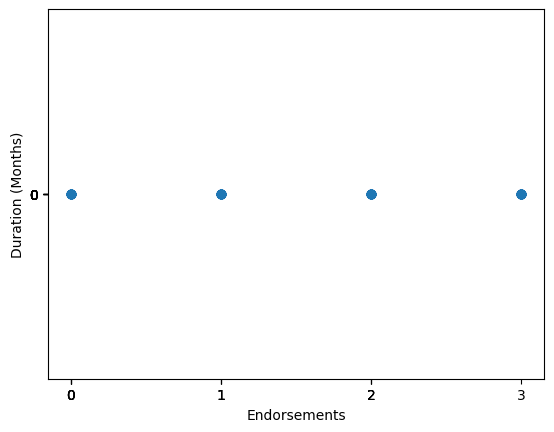

In [240]:
sub_df = skills_df[skills_df["duration_months"] == 0]
x = sub_df["endorsements"].tolist()
y = sub_df["duration_months"].tolist()

print(sub_df["candidate_id"].nunique(), skills_df["proficiency"].unique())

if len(sub_df) > 0:
    plt.scatter(x=x, y=y)
    plt.xlabel("Endorsements"), plt.ylabel("Duration (Months)")
    plt.xticks(np.linspace(np.min(x), np.max(x), 11, dtype=int).tolist()); plt.yticks(np.linspace(np.min(y), np.max(y), 11, dtype=int).tolist());
    plt.show()

In [267]:
title_and_company_size_with_exps = {title: sorted(profile_df[profile_df["current_title"] == title][["years_of_experience", "current_company_size"]].drop_duplicates().to_numpy().tolist()) for title in profile_df["current_title"].unique()}
from json import dumps
with open("text.txt", "w") as f:
    f.writelines(dumps(title_and_company_size_with_exps))

In [270]:
for key in title_and_company_size_with_exps:
    exps = [val[0] for val in title_and_company_size_with_exps[key]]
    print(key, '\n\n', np.histogram(exps, bins=np.linspace(min(exps), max(exps), 11)), '\n\n')

Backend Engineer 

 (array([24, 28, 23, 24, 25, 25, 29, 27, 24, 24], dtype=int64), array([2. , 2.6, 3.2, 3.8, 4.4, 5. , 5.6, 6.2, 6.8, 7.4, 8. ])) 


Operations Manager 

 (array([84, 83, 84, 84, 83, 83, 84, 82, 83, 90], dtype=int64), array([ 1. ,  2.4,  3.8,  5.2,  6.6,  8. ,  9.4, 10.8, 12.2, 13.6, 15. ])) 


Customer Support 

 (array([82, 83, 84, 83, 83, 84, 82, 83, 83, 89], dtype=int64), array([ 1. ,  2.4,  3.8,  5.2,  6.6,  8. ,  9.4, 10.8, 12.2, 13.6, 15. ])) 


Marketing Manager 

 (array([84, 84, 82, 83, 83, 84, 83, 84, 83, 88], dtype=int64), array([ 1. ,  2.4,  3.8,  5.2,  6.6,  8. ,  9.4, 10.8, 12.2, 13.6, 15. ])) 


Accountant 

 (array([83, 81, 83, 83, 84, 83, 82, 83, 84, 89], dtype=int64), array([ 1. ,  2.4,  3.8,  5.2,  6.6,  8. ,  9.4, 10.8, 12.2, 13.6, 15. ])) 


Business Analyst 

 (array([84, 82, 84, 83, 82, 83, 83, 83, 83, 90], dtype=int64), array([ 1. ,  2.4,  3.8,  5.2,  6.6,  8. ,  9.4, 10.8, 12.2, 13.6, 15. ])) 


Civil Engineer 

 (array([82, 84, 82, 83, 83, 82

In [287]:
role = "AI Engineer"
sub_df1 = profile_df[(profile_df["current_title"] == role) & (profile_df["years_of_experience"] > 14)]
cand_ids = sub_df1["candidate_id"].unique().tolist()
career_df[career_df["candidate_id"].isin(cand_ids)]

,Unnamed: 0,candidate_id,title,company,start_date,end_date,duration_months,is_current,industry,company_size
167996,167996,CAND_0055992,AI Engineer,CRED,2025-02-01,,16.0,True,Fintech,1001-5000
167997,167997,CAND_0055992,Senior Data Scientist,Aganitha,2023-10-26,2025-01-18 00:00:00,15.0,False,AI/ML,51-200
167998,167998,CAND_0055992,AI Engineer,Observe.AI,2020-10-11,2023-10-26 00:00:00,37.0,False,AI/ML,201-500
167999,167999,CAND_0055992,Machine Learning Engineer,Ola,2019-10-17,2020-10-11 00:00:00,12.0,False,Transportation,5001-10000
274713,274713,CAND_0091534,AI Engineer,Flipkart,2022-02-17,,52.0,True,E-commerce,10001+
274714,274714,CAND_0091534,Machine Learning Engineer,Adobe,2020-11-24,2021-12-19 00:00:00,13.0,False,Software,10001+
274715,274715,CAND_0091534,NLP Engineer,Glance,2019-03-05,2020-10-25 00:00:00,20.0,False,AI/ML,501-1000


In [288]:
role = "NLP Engineer"
sub_df1 = profile_df[(profile_df["current_title"] == role) & (profile_df["years_of_experience"] > 14)]
cand_ids = sub_df1["candidate_id"].unique().tolist()
sub_df2 = career_df[career_df["candidate_id"].isin(cand_ids)].groupby("candidate_id").agg(career_start=("start_date", lambda x: x.min()))
career_df[career_df["candidate_id"].isin(cand_ids)]

,Unnamed: 0,candidate_id,title,company,start_date,end_date,duration_months,is_current,industry,company_size
280125,280125,CAND_0093331,NLP Engineer,Genpact AI,2022-05-18,,49.0,True,AI Services,10001+
280126,280126,CAND_0093331,NLP Engineer,InMobi,2021-04-09,2022-05-04 00:00:00,13.0,False,AdTech,1001-5000
280127,280127,CAND_0093331,Recommendation Systems Engineer,Observe.AI,2019-04-06,2021-03-26 00:00:00,24.0,False,AI/ML,201-500
286963,286963,CAND_0095619,NLP Engineer,Nykaa,2022-04-18,,50.0,True,E-commerce,1001-5000


In [289]:
role = "Recommendation Systems Engineer"
sub_df1 = profile_df[(profile_df["current_title"] == role) & (profile_df["years_of_experience"] > 14)]
cand_ids = sub_df1["candidate_id"].unique().tolist()
sub_df2 = career_df[career_df["candidate_id"].isin(cand_ids)].groupby("candidate_id").agg(career_start=("start_date", lambda x: x.min()))
career_df[career_df["candidate_id"].isin(cand_ids)]

,Unnamed: 0,candidate_id,title,company,start_date,end_date,duration_months,is_current,industry,company_size
32198,32198,CAND_0010770,Recommendation Systems Engineer,Aganitha,2022-06-17,,48.0,True,AI/ML,51-200
32199,32199,CAND_0010770,AI Engineer,Verloop.io,2020-10-25,2022-06-17 00:00:00,20.0,False,Conversational AI,51-200
32200,32200,CAND_0010770,Senior Data Scientist,Observe.AI,2019-10-31,2020-10-25 00:00:00,12.0,False,AI/ML,201-500
32201,32201,CAND_0010770,Applied ML Engineer,Locobuzz,2019-04-04,2019-10-01 00:00:00,6.0,False,AI/ML,51-200
213653,213653,CAND_0071115,Recommendation Systems Engineer,Meta,2022-09-15,,45.0,True,Internet,10001+
213654,213654,CAND_0071115,AI Engineer,Krutrim,2020-09-25,2022-09-15 00:00:00,24.0,False,AI/ML,201-500


In [297]:
role = "Staff Machine Learning Engineer"
sub_df1 = profile_df[(profile_df["current_title"] == role) & (profile_df["years_of_experience"] < 6)]
cand_ids = sub_df1["candidate_id"].unique().tolist()
sub_df2 = career_df[career_df["candidate_id"].isin(cand_ids)].groupby("candidate_id").agg(career_start=("start_date", lambda x: x.min()))
career_df[career_df["candidate_id"].isin(cand_ids)]

,Unnamed: 0,candidate_id,title,company,start_date,end_date,duration_months,is_current,industry,company_size
180327,180327,CAND_0060072,Staff Machine Learning Engineer,Amazon,2023-05-13,,37.0,True,Internet,10001+
180328,180328,CAND_0060072,Senior Applied Scientist,Wysa,2020-10-11,2023-04-29 00:00:00,31.0,False,HealthTech AI,51-200


In [306]:
# role = "Junior ML Engineer"
# sub_df1 = profile_df[(profile_df["current_title"] == role) & (profile_df["years_of_experience"] > 6)]
# cand_ids = sub_df1["candidate_id"].unique().tolist()
# sub_df2 = career_df[career_df["candidate_id"].isin(cand_ids)].groupby("candidate_id").agg(career_start=("start_date", lambda x: x.min()))
# career_df[career_df["candidate_id"].isin(cand_ids[:5])]

# not a normal title progression
# CAND_0016678
# CAND_0030946
# CAND_0040955
# CAND_0032996
# CAND_0053527
# CAND_0057529
# CAND_0064256
# CAND_0067535
# CAND_0073504
# CAND_0080102
# CAND_0080291
# CAND_0088354
# CAND_0094482
# CAND_0098288
# CAND_0008978
# CAND_0012837
# CAND_0011125

,Unnamed: 0,candidate_id,title,company,start_date,end_date,duration_months,is_current,industry,company_size
7976,7976,CAND_0002706,Junior ML Engineer,Zoho,2024-06-06,,24.0,True,SaaS,10001+
7977,7977,CAND_0002706,Junior ML Engineer,InMobi,2020-06-20,2024-05-30 00:00:00,48.0,False,AdTech,1001-5000
7978,7978,CAND_0002706,ML Engineer,BYJU'S,2019-07-26,2020-05-21 00:00:00,10.0,False,EdTech,10001+
12259,12259,CAND_0004131,Junior ML Engineer,Flipkart,2024-10-04,,20.0,True,E-commerce,10001+
12260,12260,CAND_0004131,Junior ML Engineer,Observe.AI,2023-02-12,2024-09-04 00:00:00,19.0,False,AI/ML,201-500
12261,12261,CAND_0004131,Junior ML Engineer,InMobi,2019-08-02,2022-12-14 00:00:00,41.0,False,AdTech,1001-5000
26887,26887,CAND_0008978,Junior ML Engineer,Tech Mahindra,2022-11-14,,43.0,True,IT Services,10001+
26888,26888,CAND_0008978,AI Specialist,HCL,2021-08-21,2022-09-15 00:00:00,13.0,False,IT Services,10001+
26889,26889,CAND_0008978,Data Scientist,Zoho,2019-09-01,2021-08-21 00:00:00,24.0,False,SaaS,10001+
33274,33274,CAND_0011125,Junior ML Engineer,Wysa,2023-06-12,,36.0,True,HealthTech AI,51-200


In [298]:
# role = "Senior Machine Learning Engineer"
# sub_df1 = profile_df[(profile_df["current_title"] == role) & (profile_df["years_of_experience"] < 4)]
# cand_ids = sub_df1["candidate_id"].unique().tolist()
# sub_df2 = career_df[career_df["candidate_id"].isin(cand_ids)].groupby("candidate_id").agg(career_start=("start_date", lambda x: x.min()))
# career_df[career_df["candidate_id"].isin(cand_ids)]

In [295]:
# role = "Lead AI Engineer"
# sub_df1 = profile_df[(profile_df["current_title"] == role) & (profile_df["years_of_experience"] < 6.5)]
# cand_ids = sub_df1["candidate_id"].unique().tolist()
# sub_df2 = career_df[career_df["candidate_id"].isin(cand_ids)].groupby("candidate_id").agg(career_start=("start_date", lambda x: x.min()))
# career_df[career_df["candidate_id"].isin(cand_ids)]

In [296]:
# role = "Senior AI Engineer"
# sub_df1 = profile_df[(profile_df["current_title"] == role) & (profile_df["years_of_experience"] > 7.5)]
# cand_ids = sub_df1["candidate_id"].unique().tolist()
# sub_df2 = career_df[career_df["candidate_id"].isin(cand_ids)].groupby("candidate_id").agg(career_start=("start_date", lambda x: x.min()))
# career_df[career_df["candidate_id"].isin(cand_ids)]

In [321]:
###################################################

def numbers_parser(text):
    
    import re

    pattern = r'''
    (?:
        \d+(?:\.\d+)?(?:st|nd|rd|th)\b      # ordinals: 1st, 30th
        |
        \d+(?:\.\d+)?/\d+(?:\.\d+)?         # fractions: 3/5, 1.5/2.5
        |
        \d+(?:\.\d+)?-\d+(?:\.\d+)?         # ranges: 1-2, 1.5-2.5
        |
        \d+\.\d+                            # floats: 3.14
        |
        \d+                                 # integers: 42
    )
    '''

    numbers = re.findall(pattern, text, re.VERBOSE)

    return numbers

yoe_with_headline_and_summary = {yoe: sorted(profile_df[profile_df["years_of_experience"] == yoe][["headline", "summary"]].drop_duplicates().to_numpy().tolist()) for yoe in profile_df["years_of_experience"].unique()}
yoe_with_headline_and_summary = {yoe: [[numbers_parser(val[0]), numbers_parser(val[1]), val[0], val[1]] for val in texts] for yoe, texts in yoe_with_headline_and_summary.items()}
yoe_with_headline_and_summary.keys()

dict_keys([6.9, 12.5, 1.1, 3.8, 11.0, 6.0, 5.5, 3.6, 4.6, 2.0, 8.4, 5.4, 5.3, 12.3, 6.6, 6.5, 6.3, 14.5, 3.7, 7.5, 7.3, 6.8, 3.9, 7.2, 10.0, 8.1, 8.6, 4.3, 11.3, 14.3, 6.7, 1.6, 13.7, 5.0, 8.3, 5.7, 12.2, 7.8, 2.4, 9.7, 11.8, 13.5, 6.2, 1.4, 4.9, 1.3, 3.3, 10.1, 1.5, 8.0, 7.7, 4.5, 13.0, 4.2, 1.8, 7.0, 12.1, 1.9, 5.2, 12.0, 8.7, 10.3, 13.2, 7.4, 10.6, 12.9, 2.5, 7.6, 1.7, 4.8, 8.2, 2.6, 3.2, 5.8, 11.7, 11.5, 2.2, 9.8, 7.9, 8.5, 10.9, 5.6, 5.1, 14.7, 3.4, 13.9, 14.9, 4.0, 9.9, 3.1, 4.4, 12.4, 13.8, 9.1, 10.7, 2.9, 2.7, 4.7, 6.1, 5.9, 14.1, 3.5, 9.2, 3.0, 9.5, 11.1, 4.1, 10.4, 13.3, 10.2, 11.4, 2.3, 14.4, 14.8, 2.1, 9.0, 12.6, 9.4, 12.8, 2.8, 9.6, 6.4, 7.1, 15.0, 14.2, 14.0, 12.7, 9.3, 11.6, 8.8, 11.9, 10.8, 11.2, 13.1, 1.2, 10.5, 14.6, 13.4, 13.6, 8.9, 1.0, 15.2, 16.2, 16.9, 16.5, 16.6, 16.1, 15.6])

,candidate_id,years_of_experience,headline,summary
18498,CAND_0018499,7.2,Senior Machine Learning Engineer | Building AI-native search & ranking systems,"Senior AI engineer with 7.2 years of hands-on experience building production ML systems, with a focus on search, retrieval, and ranking. Most recently, I designed the company's first hybrid retrieval system combining BM25 with dense vector recall, serving 50M+ queries per month. My day-to-day work spans embedding model selection and fine-tuning, hybrid retrieval architecture, learning-to-rank, behavioral-signal integration, and the offline/online evaluation that ties it all together. I've shipped systems in both early-stage product companies and at larger scale, and I've spent enough time on both that I know which tradeoffs apply where. I have strong opinions about when LLMs are the right hammer and when classical IR is — usually it's both. Currently exploring my next move — looking for senior IC or tech-lead roles where I can own the intelligence layer end-to-end."
46524,CAND_0046525,6.1,Senior Machine Learning Engineer | Building AI-native search & ranking systems,"Senior AI engineer with 6.1 years of hands-on experience building production ML systems, with a focus on search, retrieval, and ranking. Most recently, I designed the company's first hybrid retrieval system combining BM25 with dense vector recall, handling peak QPS of 8K with sub-200ms p95. My day-to-day work spans embedding model selection and fine-tuning, hybrid retrieval architecture, learning-to-rank, behavioral-signal integration, and the offline/online evaluation that ties it all together. I've shipped systems in both early-stage product companies and at larger scale, and I've spent enough time on both that I know which tradeoffs apply where. I care more about shipping a working system in 6 weeks than a theoretically perfect one in 6 months. Currently exploring my next move — looking for senior IC or tech-lead roles where I can own the intelligence layer end-to-end."
93546,CAND_0093547,2.9,Senior Machine Learning Engineer | Building AI-native search & ranking systems,"Senior AI engineer with 6.3 years of hands-on experience building production ML systems, with a focus on search, retrieval, and ranking. Most recently, I rebuilt the candidate-JD matching pipeline from scratch, taking it from 0.72 to 0.91 NDCG@10, handling peak QPS of 8K with sub-200ms p95. My day-to-day work spans embedding model selection and fine-tuning, hybrid retrieval architecture, learning-to-rank, behavioral-signal integration, and the offline/online evaluation that ties it all together. I've shipped systems in both early-stage product companies and at larger scale, and I've spent enough time on both that I know which tradeoffs apply where. I believe most ranking problems are solved by careful feature engineering and rigorous eval, not by bigger models. Currently exploring my next move — looking for senior IC or tech-lead roles where I can own the intelligence layer end-to-end."


In [336]:
for i, key in enumerate(sorted(list([14.1]))):#, 14.1, 15.2, 15.6, 16.1, 16.2, 16.5, 16.6, 16.9]))):
    print(f"{i+1} / {len(yoe_with_headline_and_summary)}: ", key, '\n\n')
    for val in yoe_with_headline_and_summary[key]:
        if ((len(val[0]) > 0) and (str(key) not in val[0])) or ((len(val[1]) > 0) and (str(key) not in val[1])):
            print(profile_df[profile_df["headline"] == val[2]][["candidate_id", "years_of_experience", "headline", "summary"]])
    print('\n')
    _ = input()
    
# 2.7, 6.3
# 2.8, 7.4
# 2.9, 6.3
# 3.0, 5.2
# 3.0, 5.0
# 14.1, 4.8
# 15.2, 7.2
# 15.6, 4.2
# 16.1, 7.2
# 16.2, 8.3
# 16.5, 5.8
# 16.6, 7.2
# 16.9, 6.8

# mismatching total experience and that mentioned in profile headline / summary
# CAND_0013536
# CAND_0050876
# CAND_0074735
# CAND_0010770
# CAND_0095619
# CAND_0093331
# CAND_0039754
# CAND_0071115
# CAND_0091534
# CAND_0055992

1 / 148:  14.1 


       candidate_id  years_of_experience  \
7411   CAND_0007412                  7.4   
9690   CAND_0009691                  6.2   
13535  CAND_0013536                 14.1   
50875  CAND_0050876                  6.0   
74734  CAND_0074735                  5.5   

                                                    headline  \
7411   Applied ML Engineer | ML, NLP, Recommendation Systems   
9690   Applied ML Engineer | ML, NLP, Recommendation Systems   
13535  Applied ML Engineer | ML, NLP, Recommendation Systems   
50875  Applied ML Engineer | ML, NLP, Recommendation Systems   
74734  Applied ML Engineer | ML, NLP, Recommendation Systems   

                                                                                                                                                                                                                                                                                                                                            

In [98]:
career_profile_merged_df = profile_df.merge(career_df[career_df["is_current"]], on="candidate_id", how="left").head()
career_profile_merged_df[(career_profile_merged_df["duration_months"] / 12) > career_profile_merged_df["years_of_experience"]]

,candidate_id,name,headline,summary,location,country,years_of_experience,current_title,current_company,current_company_size,current_industry,Unnamed: 0,title,company,start_date,end_date,duration_months,is_current,industry,company_size


In [114]:
career_df["start_date"] = pd.to_datetime(career_df["start_date"])
career_df["end_date"] = pd.to_datetime(career_df["end_date"])

df = df.sort_values(
    ["candidate_id", "start_date"]
).copy()

# Replace current roles (NaT end dates) with a far future date
df["effective_end"] = df["end_date"].fillna(pd.Timestamp.max)

# Previous maximum end date for the candidate
df["previous_max_end"] = (
    df.groupby("candidate_id")["effective_end"]
      .cummax()
      .shift()
)

# Strict overlap check
df["has_overlap"] = (
    (df["candidate_id"] == df["candidate_id"].shift()) &
    (df["start_date"] < df["previous_max_end"])
)

overlapping_candidates = df.loc[df["has_overlap"]]
overlapping_candidates

,Unnamed: 0,candidate_id,title,company,start_date,end_date,duration_months,is_current,industry,company_size,previous_max_end,has_overlap,effective_end


In [110]:
career_df["candidate_id"].nunique(), overlapping_roles["candidate_id"].nunique()

(100000, 60803)

In [117]:
career_df["is_current_int"] = career_df["is_current"].astype(int)
grouped_current_roles = career_df.groupby("candidate_id").agg({"is_current_int": lambda x: x.sum()}).head(10)
grouped_current_roles[grouped_current_roles["is_current_int"] > 1]

,is_current_int
candidate_id,


In [125]:
career_df["end_date"] = career_df["end_date"].apply(lambda x: "" if (type(x) == pd._libs.tslibs.nattype.NaTType) else x)
career_df[(career_df["is_current"] & (career_df["end_date"] != "")) | (~career_df["is_current"] & (career_df["end_date"] == ""))]

In [242]:
edu_overlap_with_career = education_df.merge(career_df.groupby("candidate_id").agg({"start_date": lambda x: x.min()}), on="candidate_id", how="left")
edu_overlap_with_career["career_start_year"] = edu_overlap_with_career["start_date"].apply(lambda x: int(x.year))
edu_overlap_with_career[(edu_overlap_with_career["career_start_year"] < edu_overlap_with_career["end_year"]) & edu_overlap_with_career["career_start_year"] > edu_overlap_with_career["start_year"]]

,Unnamed: 0,candidate_id,degree,field_of_study,grade,institution,tier,start_year,end_year,start_date,career_start_year


In [243]:
edu_overlap_with_career = education_df.merge(career_df.groupby("candidate_id").agg({
    "start_date": lambda x: sorted([d.year for d in x]),
    "title": lambda x: " | ".join(x.tolist())
}), on="candidate_id", how="left")

edu_overlap_with_career["has_overlap"] = edu_overlap_with_career.apply(
    lambda row: any((row["start_year"] < x < row["end_year"]) and ((row["end_year"] - x) > 1) for x in row["start_date"]),
    axis=1
)

print(edu_overlap_with_career[edu_overlap_with_career["has_overlap"]]["candidate_id"].nunique())

edu_overlap_with_career[edu_overlap_with_career["has_overlap"]]

15221


,Unnamed: 0,candidate_id,degree,field_of_study,grade,institution,tier,start_year,end_year,start_date,title,has_overlap
27,27,CAND_0000020,B.E.,Computer Science,6.67 CGPA,IIT Kharagpur,tier_1,2018,2022,"[2020, 2020, 2023]",Mechanical Engineer | Graphic Designer | Civil Engineer,True
40,40,CAND_0000030,Ph.D,Artificial Intelligence,7.98 CGPA,Generic State University,tier_4,2017,2020,"[2016, 2018, 2022]",Marketing Manager | Sales Executive | Content Writer,True
42,42,CAND_0000032,M.Sc,Machine Learning,8.37 CGPA,VIT Chennai,tier_3,2017,2020,"[2018, 2021, 2024]",.NET Developer | Cloud Engineer | Mobile Developer,True
55,55,CAND_0000041,M.S.,Machine Learning,8.73 CGPA,Local Engineering College,tier_4,2013,2018,"[2013, 2014, 2019, 2021, 2022]",Operations Manager | Business Analyst | Content Writer | Content Writer | Mechanical Engineer,True
63,63,CAND_0000045,B.Tech,Machine Learning,86%,KIIT University,tier_3,2016,2020,"[2014, 2016, 2018, 2021, 2023, 2024, 2025]",Project Manager | Civil Engineer | Marketing Manager | Content Writer | Graphic Designer | Graphic Designer | Operations Manager,True
...,...,...,...,...,...,...,...,...,...,...,...,...
139714,139714,CAND_0099957,B.E.,Computer Science,6.59 CGPA,Christ University,tier_3,2018,2022,"[2017, 2020, 2023]",Software Engineer | Full Stack Developer | Cloud Engineer,True
139763,139763,CAND_0099992,B.Sc,Mathematics,8.20 CGPA,Amity University,tier_3,2012,2017,"[2012, 2012, 2014, 2016, 2020, 2024]",Project Manager | Civil Engineer | Marketing Manager | Project Manager | Civil Engineer | Content Writer,True
139764,139764,CAND_0099992,M.S.,Physics,6.57 CGPA,Chandigarh University,tier_3,2015,2019,"[2012, 2012, 2014, 2016, 2020, 2024]",Project Manager | Civil Engineer | Marketing Manager | Project Manager | Civil Engineer | Content Writer,True
139765,139765,CAND_0099993,B.Tech,Artificial Intelligence,8.56 CGPA,IIT Madras,tier_1,2018,2022,"[2017, 2019, 2021, 2024]",Cloud Engineer | Mobile Developer | Frontend Engineer | Software Engineer,True


In [199]:
lang_sub_df = languages_df.groupby("candidate_id").agg(all_native=("proficiency", lambda x: (len(x) > 1) and all(prof == "native" for prof in x)))
print(languages_df.merge(lang_sub_df[lang_sub_df["all_native"]], on="candidate_id", how="right")["candidate_id"].nunique())
languages_df.merge(lang_sub_df[lang_sub_df["all_native"]], on="candidate_id", how="right")

16742


,Unnamed: 0,candidate_id,language,proficiency,all_native
0,34,CAND_0000018,English,native,True
1,35,CAND_0000018,Hindi,native,True
2,44,CAND_0000023,English,native,True
3,45,CAND_0000023,Hindi,native,True
4,50,CAND_0000026,English,native,True
...,...,...,...,...,...
33479,199917,CAND_0099959,Hindi,native,True
33480,199922,CAND_0099962,English,native,True
33481,199923,CAND_0099962,Hindi,native,True
33482,199978,CAND_0099990,English,native,True


In [200]:
redrob_df.columns

Index(['Unnamed: 0', 'candidate_id', 'profile_completeness_score',
       'signup_date', 'last_active_date', 'open_to_work_flag',
       'profile_views_received_30d', 'applications_submitted_30d',
       'recruiter_response_rate', 'avg_response_time_hours',
       'skill_assessment_scores', 'connection_count', 'endorsements_received',
       'notice_period_days', 'expected_salary_range_inr_lpa',
       'preferred_work_mode', 'willing_to_relocate', 'github_activity_score',
       'search_appearance_30d', 'saved_by_recruiters_30d',
       'interview_completion_rate', 'offer_acceptance_rate', 'verified_email',
       'verified_phone', 'linkedin_connected'],
      dtype='object')

In [202]:
redrob_df[(redrob_df["recruiter_response_rate"] > 0.9) & (redrob_df["applications_submitted_30d"] == 0)]

,Unnamed: 0,candidate_id,profile_completeness_score,signup_date,last_active_date,open_to_work_flag,profile_views_received_30d,applications_submitted_30d,recruiter_response_rate,avg_response_time_hours,...,preferred_work_mode,willing_to_relocate,github_activity_score,search_appearance_30d,saved_by_recruiters_30d,interview_completion_rate,offer_acceptance_rate,verified_email,verified_phone,linkedin_connected
50552,50552,CAND_0050553,87.2,2025-11-02,2026-05-26,True,164,0,0.95,10.7,...,onsite,True,70.3,632,50,0.52,0.46,True,True,False
61264,61264,CAND_0061265,86.5,2024-08-06,2026-03-25,True,208,0,0.94,5.7,...,hybrid,False,79.8,461,24,0.57,-1.00,True,False,False
78041,78041,CAND_0078042,92.4,2024-10-24,2026-04-24,False,10,0,0.91,3.5,...,remote,False,83.6,1085,6,0.92,0.88,True,True,False


In [203]:
redrob_df[(redrob_df["recruiter_response_rate"] == 0) & (redrob_df["avg_response_time_hours"] > 0)]

,Unnamed: 0,candidate_id,profile_completeness_score,signup_date,last_active_date,open_to_work_flag,profile_views_received_30d,applications_submitted_30d,recruiter_response_rate,avg_response_time_hours,...,preferred_work_mode,willing_to_relocate,github_activity_score,search_appearance_30d,saved_by_recruiters_30d,interview_completion_rate,offer_acceptance_rate,verified_email,verified_phone,linkedin_connected


In [208]:
print(redrob_df[redrob_df["saved_by_recruiters_30d"] > redrob_df["profile_views_received_30d"]]["candidate_id"].nunique())
redrob_df[redrob_df["saved_by_recruiters_30d"] > redrob_df["profile_views_received_30d"]]

7677


,Unnamed: 0,candidate_id,profile_completeness_score,signup_date,last_active_date,open_to_work_flag,profile_views_received_30d,applications_submitted_30d,recruiter_response_rate,avg_response_time_hours,...,preferred_work_mode,willing_to_relocate,github_activity_score,search_appearance_30d,saved_by_recruiters_30d,interview_completion_rate,offer_acceptance_rate,verified_email,verified_phone,linkedin_connected
1,1,CAND_0000002,78.7,2025-07-28,2025-11-12,True,7,1,0.29,171.6,...,flexible,False,-1.0,107,10,0.62,-1.00,False,False,False
2,2,CAND_0000003,31.9,2024-08-02,2026-03-21,False,1,9,0.46,119.4,...,hybrid,False,-1.0,28,4,0.86,-1.00,True,False,False
3,3,CAND_0000004,28.5,2025-07-21,2026-03-25,False,3,9,0.26,104.1,...,onsite,True,-1.0,5,8,0.35,-1.00,True,True,True
6,6,CAND_0000007,74.6,2025-09-29,2026-05-25,False,2,1,0.62,61.3,...,onsite,True,-1.0,104,8,0.47,-1.00,True,True,True
20,20,CAND_0000021,58.5,2026-02-10,2025-11-21,False,1,8,0.49,98.7,...,hybrid,True,6.4,8,3,0.53,-1.00,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99913,99913,CAND_0099914,32.3,2025-02-01,2026-04-06,True,2,8,0.40,37.5,...,remote,False,-1.0,139,12,0.42,-1.00,True,True,True
99917,99917,CAND_0099918,73.2,2023-03-25,2025-12-28,False,10,4,0.75,237.9,...,hybrid,False,42.4,118,12,0.38,0.67,True,True,True
99944,99944,CAND_0099945,35.1,2023-02-21,2026-01-27,False,0,2,0.34,269.8,...,flexible,False,-1.0,86,7,0.73,0.62,True,True,True
99972,99972,CAND_0099973,48.4,2025-05-08,2026-04-21,False,5,8,0.72,97.6,...,onsite,True,-1.0,79,6,0.73,-1.00,False,True,False


In [209]:
print(redrob_df[redrob_df["offer_acceptance_rate"] > redrob_df["interview_completion_rate"]]["candidate_id"].nunique())
redrob_df[redrob_df["offer_acceptance_rate"] > redrob_df["interview_completion_rate"]]

10760


,Unnamed: 0,candidate_id,profile_completeness_score,signup_date,last_active_date,open_to_work_flag,profile_views_received_30d,applications_submitted_30d,recruiter_response_rate,avg_response_time_hours,...,preferred_work_mode,willing_to_relocate,github_activity_score,search_appearance_30d,saved_by_recruiters_30d,interview_completion_rate,offer_acceptance_rate,verified_email,verified_phone,linkedin_connected
26,26,CAND_0000027,31.0,2023-03-07,2026-05-07,True,89,5,0.58,112.3,...,hybrid,False,38.6,136,6,0.61,0.65,False,True,True
55,55,CAND_0000056,37.7,2024-02-15,2025-11-30,False,4,1,0.59,155.0,...,flexible,False,-1.0,213,8,0.47,0.64,True,True,False
69,69,CAND_0000070,74.6,2024-07-24,2026-04-27,False,65,7,0.06,249.8,...,flexible,False,-1.0,96,1,0.65,0.69,False,False,True
87,87,CAND_0000088,32.1,2025-08-05,2026-02-24,False,21,3,0.53,62.7,...,flexible,True,-1.0,233,2,0.66,0.69,True,False,False
91,91,CAND_0000092,64.3,2025-03-23,2025-11-01,False,29,8,0.05,15.8,...,hybrid,False,-1.0,53,12,0.34,0.42,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99967,99967,CAND_0099968,39.5,2024-11-13,2026-04-26,False,8,0,0.76,121.6,...,hybrid,False,-1.0,83,3,0.35,0.59,True,True,False
99974,99974,CAND_0099975,79.5,2024-12-17,2025-12-29,True,27,4,0.50,52.6,...,onsite,False,-1.0,96,6,0.55,0.77,True,True,False
99976,99976,CAND_0099977,61.2,2025-05-20,2026-04-21,True,67,8,0.42,80.0,...,onsite,False,-1.0,100,2,0.56,0.76,True,True,True
99982,99982,CAND_0099983,74.1,2024-11-30,2026-02-19,True,140,14,0.23,106.5,...,flexible,False,-1.0,471,17,0.62,0.72,True,True,True


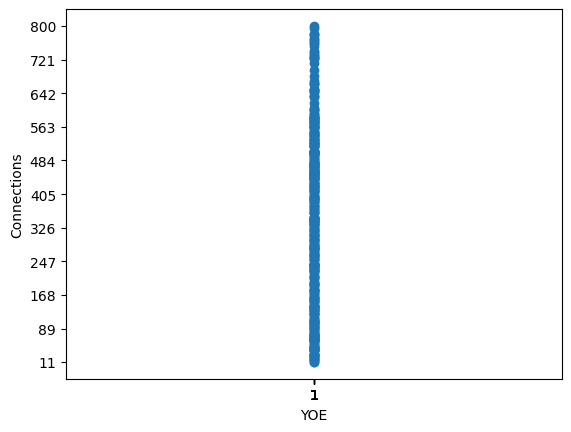

In [214]:
sub_df = profile_df[["candidate_id", "years_of_experience"]].merge(redrob_df[["candidate_id", "connection_count"]], on="candidate_id", how="left")
sub_df = sub_df[sub_df["years_of_experience"] <= 1]

x = sub_df["years_of_experience"].tolist()
y = sub_df["connection_count"].tolist()

# print(sub_df["candidate_id"].nunique(), skills_df["proficiency"].unique())

if len(sub_df) > 0:
    plt.scatter(x=x, y=y)
    plt.xlabel("YOE"), plt.ylabel("Connections")
    plt.xticks(np.linspace(np.min(x), np.max(x), 11, dtype=float).tolist()); plt.yticks(np.linspace(np.min(y), np.max(y), 11, dtype=int).tolist());
    plt.show()

In [219]:
sub_df = career_df.groupby("candidate_id").agg(no_current_job=("is_current", lambda x: not any(x.tolist())))
# sub_df = sub_df[sub_df["no_current_job"]].merge(redrob_df[redrob_df["notice_period_days"] == 0], on="candidate_id", how="left")
sub_df["no_current_job"].unique()

array([False])

### Selected Honeypot rules

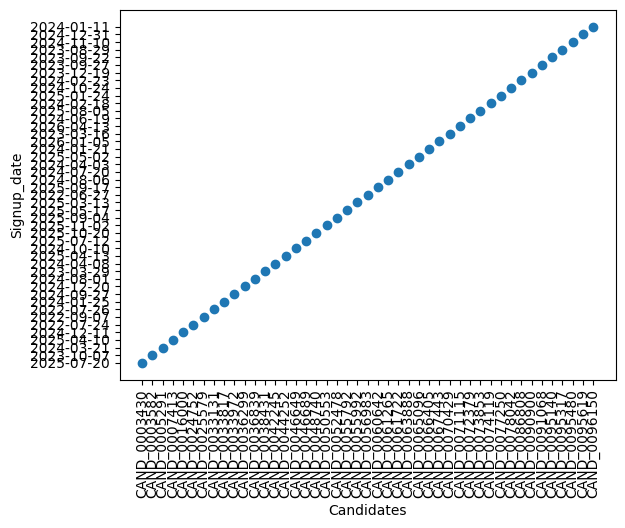

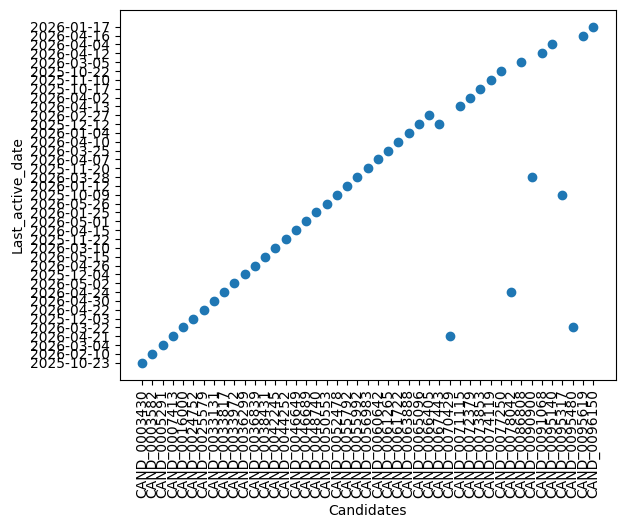

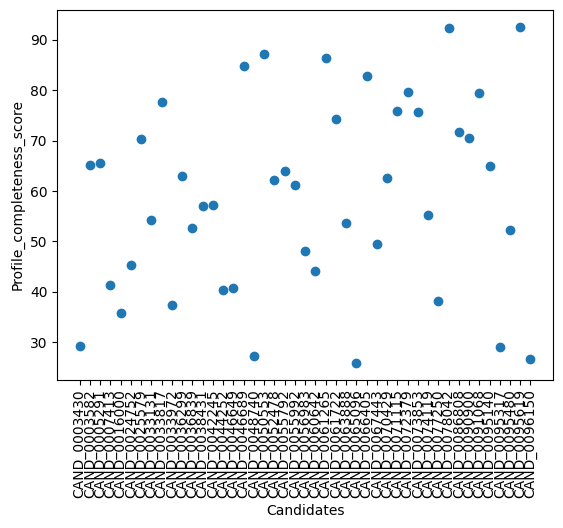

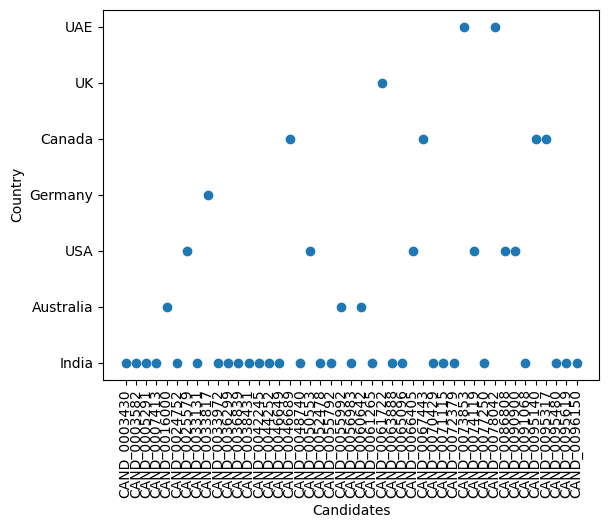

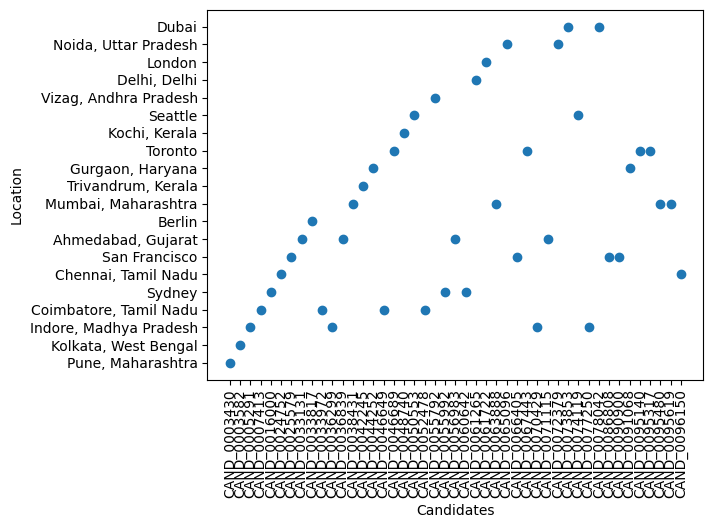

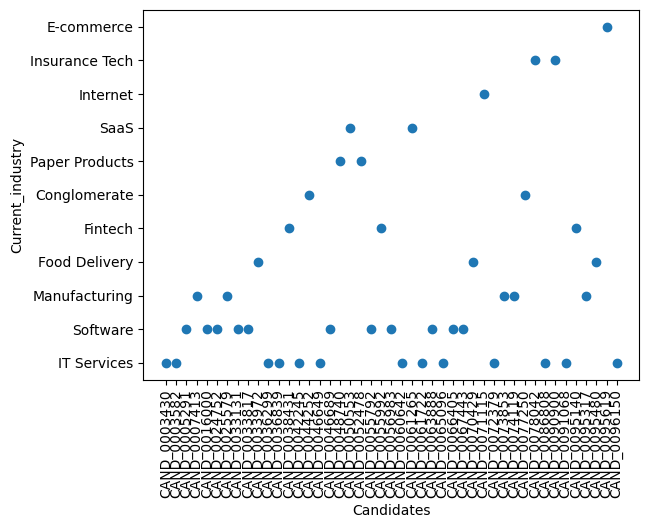

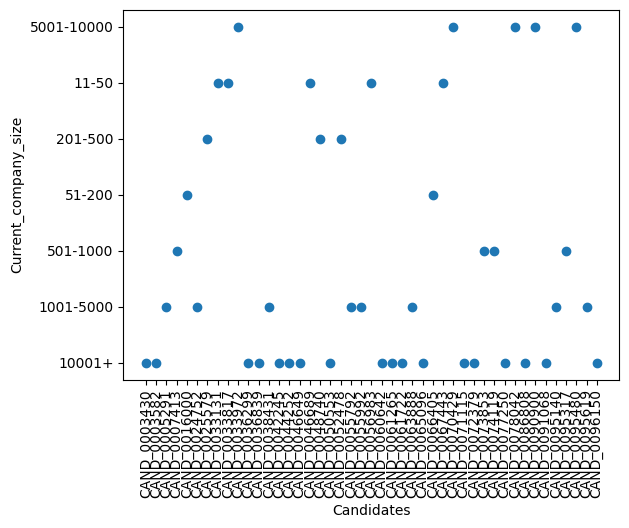

In [264]:
honeypots_signals = redrob_df[redrob_df["candidate_id"].isin(honeypots)]

x = honeypots_signals["candidate_id"].tolist()

for key in ["signup_date", "last_active_date", "profile_completeness_score"]:
    
    if "date" in key:
        y = [date for date in honeypots_signals[key].tolist()]
    else:
        y = [float(score) for score in honeypots_signals[key].tolist()]
        
    plt.scatter(x, y)
    plt.xlabel("Candidates"), plt.ylabel(key.capitalize())
    plt.xticks(rotation=90)
    plt.show()
    
honeypots_profiles = profile_df[profile_df["candidate_id"].isin(honeypots)]
    
for key in ["country", "location", "current_industry", "current_company_size"]:
    
    y = [date for date in honeypots_profiles[key].tolist()]
        
    plt.scatter(x, y)
    plt.xlabel("Candidates"), plt.ylabel(key.capitalize())
    plt.xticks(rotation=90)
    plt.show()

In [248]:
# total experience as per career history > total experience as per profile
total_exp_df = career_df.groupby("candidate_id", as_index=False).agg({'duration_months': lambda x: round(x.sum() / 12, ndigits=2)})
total_exp_df = total_exp_df.merge(profile_df[["candidate_id", "years_of_experience"]], on="candidate_id", how="left")
total_exp_df[total_exp_df["duration_months"] < total_exp_df["years_of_experience"]]

total_exp_df["exp_diff"] = total_exp_df["years_of_experience"] - total_exp_df["duration_months"]
print(total_exp_df[total_exp_df["exp_diff"] > 10]["candidate_id"].nunique())
rule1_df = total_exp_df[total_exp_df["exp_diff"] > 10]

19


In [249]:
print(skills_df[(skills_df["proficiency"] == "expert") & (skills_df["duration_months"] == 0)]["candidate_id"].nunique())
rule2_df = skills_df[(skills_df["proficiency"] == "expert") & (skills_df["duration_months"] == 0)]

21


In [250]:
print(skills_df[(skills_df["proficiency"] == "advanced") & (skills_df["duration_months"] < 3)]["candidate_id"].nunique())
rule3_df = skills_df[(skills_df["proficiency"] == "advanced") & (skills_df["duration_months"] < 3)]

2


In [251]:
rule4_df = redrob_df[(redrob_df["recruiter_response_rate"] > 0.9) & (redrob_df["applications_submitted_30d"] == 0)]

In [308]:
# Career history based experience and profile based experience do not correlate with each other for the title
roles = ["AI Engineer", "NLP Engineer", "Recommendation Systems Engineer"]
sub_df1 = profile_df[(profile_df["current_title"] == role) & (profile_df["years_of_experience"] > 14)]
cand_ids1 = sub_df1["candidate_id"].unique().tolist()
# sub_df2 = career_df[career_df["candidate_id"].isin(cand_ids)].groupby("candidate_id").agg(career_start=("start_date", lambda x: x.min()))
# career_df[career_df["candidate_id"].isin(cand_ids)]

# Total experience does not correlate with title especially for a bigger company
role = "Staff Machine Learning Engineer"
sub_df1 = profile_df[(profile_df["current_title"] == role) & (profile_df["years_of_experience"] < 6)]
cand_ids2 = sub_df1["candidate_id"].unique().tolist()
# sub_df2 = career_df[career_df["candidate_id"].isin(cand_ids)].groupby("candidate_id").agg(career_start=("start_date", lambda x: x.min()))
# career_df[career_df["candidate_id"].isin(cand_ids)]

# role = "Junior ML Engineer"
# sub_df1 = profile_df[(profile_df["current_title"] == role) & (profile_df["years_of_experience"] > 6)]
# cand_ids = sub_df1["candidate_id"].unique().tolist()
# sub_df2 = career_df[career_df["candidate_id"].isin(cand_ids)].groupby("candidate_id").agg(career_start=("start_date", lambda x: x.min()))
# career_df[career_df["candidate_id"].isin(cand_ids[:5])]

# not a normal title progression
# CAND_0016678
# CAND_0030946
# CAND_0040955
# CAND_0032996
# CAND_0053527
# CAND_0057529
# CAND_0064256
# CAND_0067535
# CAND_0073504
# CAND_0080102
# CAND_0080291
# CAND_0088354
# CAND_0094482
# CAND_0098288
# CAND_0008978
# CAND_0012837
# CAND_0011125

# mismatch between total experience in profile and profile heading / summary
# CAND_0013536
# CAND_0050876
# CAND_0074735
# CAND_0010770
# CAND_0095619
# CAND_0093331
# CAND_0039754
# CAND_0071115
# CAND_0091534
# CAND_0055992

In [337]:
wrong_experience_and_summary_candidates = ["CAND_0013536", "CAND_0050876", "CAND_0074735", "CAND_0010770", "CAND_0095619", "CAND_0093331", "CAND_0039754", "CAND_0071115", "CAND_0091534", "CAND_0055992"]
wrong_title_progression_candidates = ["CAND_0016678", "CAND_0030946", "CAND_0040955", "CAND_0032996", "CAND_0053527", "CAND_0057529", "CAND_0064256", "CAND_0067535", "CAND_0073504", "CAND_0080102", "CAND_0080291", "CAND_0088354", "CAND_0094482", "CAND_0098288", "CAND_0008978", "CAND_0012837", "CAND_0011125"]
wrong_total_exp_for_title_candidates = cand_ids1 + cand_ids2
honeypots = np.unique(rule1_df["candidate_id"].unique().tolist() + rule2_df["candidate_id"].unique().tolist() + rule3_df["candidate_id"].unique().tolist() + rule4_df["candidate_id"].unique().tolist() + wrong_title_progression_candidates + wrong_total_exp_for_title_candidates + wrong_experience_and_summary_candidates).tolist()
len(honeypots), honeypots

(70,
 ['CAND_0003430',
  'CAND_0003582',
  'CAND_0005291',
  'CAND_0007413',
  'CAND_0008978',
  'CAND_0010770',
  'CAND_0011125',
  'CAND_0012837',
  'CAND_0013536',
  'CAND_0016000',
  'CAND_0016678',
  'CAND_0024752',
  'CAND_0025579',
  'CAND_0030946',
  'CAND_0032996',
  'CAND_0033131',
  'CAND_0033817',
  'CAND_0033972',
  'CAND_0036299',
  'CAND_0036839',
  'CAND_0038431',
  'CAND_0039754',
  'CAND_0040955',
  'CAND_0042245',
  'CAND_0044252',
  'CAND_0046649',
  'CAND_0046689',
  'CAND_0048740',
  'CAND_0050553',
  'CAND_0050876',
  'CAND_0052478',
  'CAND_0053527',
  'CAND_0055792',
  'CAND_0055992',
  'CAND_0056983',
  'CAND_0057529',
  'CAND_0060072',
  'CAND_0060642',
  'CAND_0061265',
  'CAND_0061722',
  'CAND_0063888',
  'CAND_0064256',
  'CAND_0065096',
  'CAND_0066405',
  'CAND_0067443',
  'CAND_0067535',
  'CAND_0070429',
  'CAND_0071115',
  'CAND_0072379',
  'CAND_0073504',
  'CAND_0073853',
  'CAND_0074119',
  'CAND_0074735',
  'CAND_0077250',
  'CAND_0078042',
  'CA